DATASET: 2D Gaussian Modeling
Points (x, y, z):
  0: (1, 1) -> z=0
  1: (2, 1) -> z=1
  2: (3, 3) -> z=5
  3: (4, 5) -> z=1
  4: (5, 5) -> z=0

STEP 1: INITIAL PARAMETER ESTIMATION (Heuristic)
Initial Parameters:
  Amplitude (A):     5.100
  Center (x0, y0):   (3.00, 3.00)
  Sigma_x:           0.707
  Sigma_y:           0.894
  Theta (rotation):  0.000 rad
  Offset:            0.000

Initial Loss (MSE): 0.288305

STEP 2: PARAMETER OPTIMIZATION (BFGS Algorithm)
Iter   0 | Loss: 0.087719 | A=5.094, x0=3.00, y0=3.00, σx=0.804, σy=1.087
Iter   5 | Loss: 0.002393 | A=4.982, x0=3.00, y0=3.00, σx=0.770, σy=1.436
Iter  10 | Loss: 0.000000 | A=5.082, x0=3.00, y0=3.00, σx=0.706, σy=1.491

STEP 3: OPTIMIZATION RESULTS

OPTIMAL PARAMETERS:
  Amplitude (A):     5.0821
  Center (x0, y0):   (3.0000, 3.0000)
  Sigma_x:           0.7057
  Sigma_y:           1.4909
  Theta (rotation):  -0.1282 rad (-7.35°)
  Offset:            -0.0821

Final Loss (MSE):  0.00000000
Success: True
Message: CONVERGENCE: NO

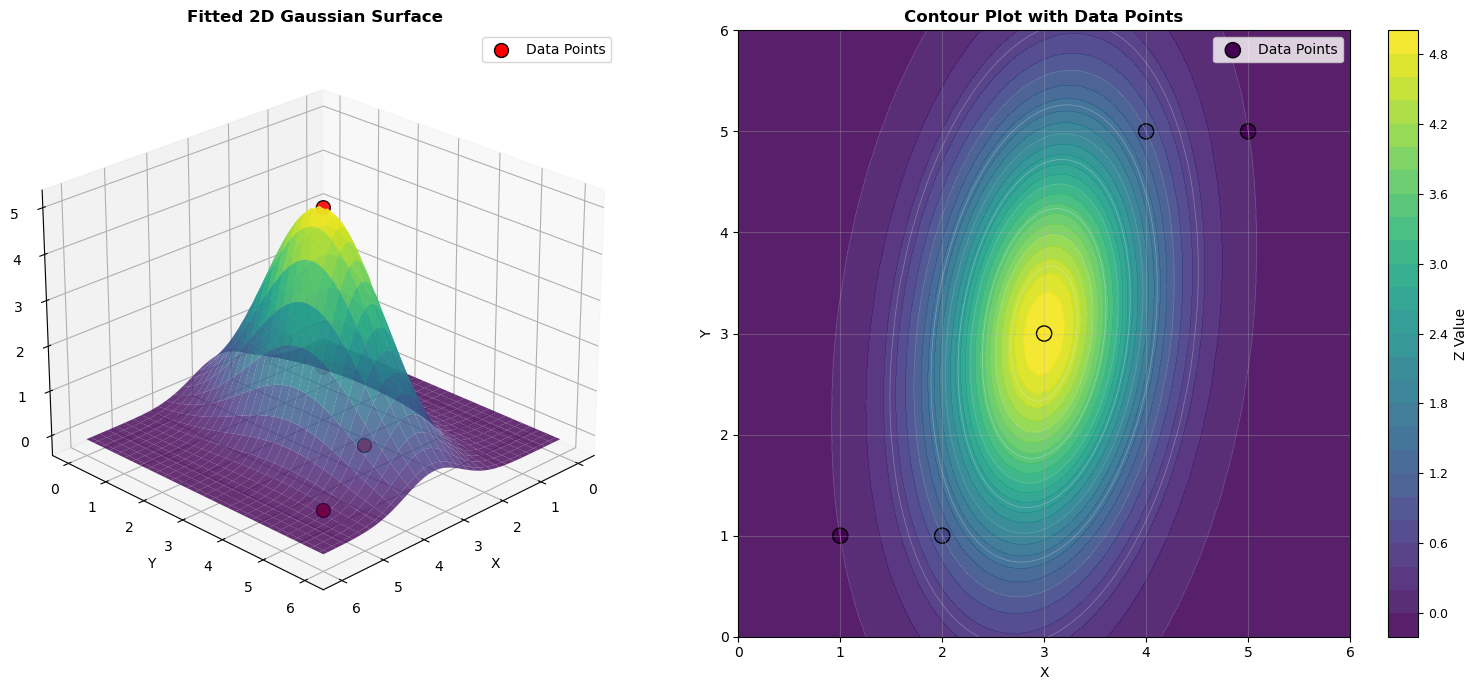


OPTIMIZATION CONVERGENCE
Convergence plot saved as 'convergence.png'


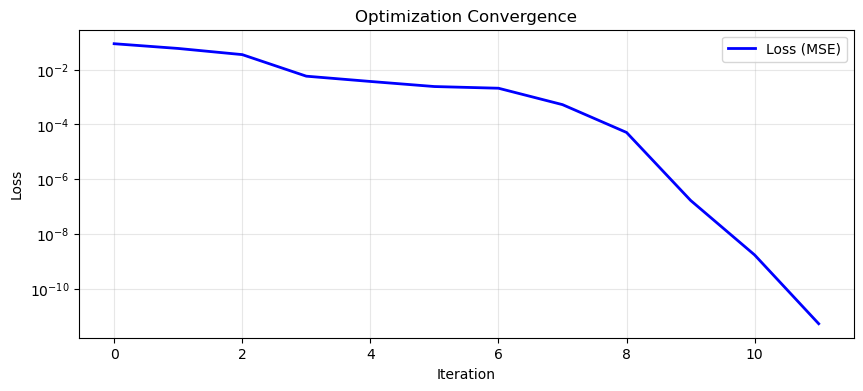


FINAL MODEL EQUATION

z(x,y) = 5.0821 * exp(-Q) + -0.0821

Where Q = (x - 3.0000)² / (2 * 0.7057²) + (y - 3.0000)² / (2 * 1.4909²)

With rotation: θ = -7.35°
Note: Coordinates are rotated before applying the Gaussian

Model Interpretation:
  • Peak location: (3.00, 3.00)
  • Peak height: 5.000 (including offset)
  • Spread in X: ±1.41 units (≈95% of mass)
  • Spread in Y: ±2.98 units (≈95% of mass)


In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configure numpy printing
np.set_printoptions(precision=4, suppress=True, linewidth=120)

# ==============================================================================
# DATASET CREATION
# ==============================================================================
data = np.array([
    [0.85, 1.12, 0.73],
    [1.83, 2.20, 3.65],
    [2.91, 3.12, 4.86],
    [3.93, 3.92, 2.00],
    [4.86, 4.94, 0.32]
])

X = data[:, 0]  # x-coordinates: [1, 2, 3, 4, 5]
Y = data[:, 1]  # y-coordinates: [1, 1, 3, 5, 5]
Z = data[:, 2]  # z-values (target): [0, 1, 5, 1, 0]

print("="*70)
print("DATASET: 2D Gaussian Modeling")
print("="*70)
print(f"Points (x, y, z):")
for i in range(len(data)):
    print(f"  {i}: ({X[i]}, {Y[i]}) -> z={Z[i]}")
print()

# ==============================================================================
# 2D GAUSSIAN FUNCTION DEFINITION
# ==============================================================================
def gaussian_2d(xy, A, x0, y0, sigma_x, sigma_y, theta=0, offset=0):
    """
    2D Gaussian Function (with optional rotation and offset)
    
    z = A * exp(-Q) + offset
    
    Where Q is the quadratic form:
    Q = a*(x-x0)^2 + 2*b*(x-x0)*(y-y0) + c*(y-y0)^2
    
    Parameters:
    - xy: tuple (x, y) or array of shape (N, 2)
    - A: Amplitude (peak height)
    - x0, y0: Center coordinates
    - sigma_x, sigma_y: Standard deviations
    - theta: Rotation angle in radians (optional)
    - offset: Vertical offset (baseline)
    """
    if isinstance(xy, tuple):
        x, y = xy
    else:
        x, y = xy[:, 0], xy[:, 1]
    
    # Rotate coordinates if theta != 0
    if theta != 0:
        dx = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
        dy = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    else:
        dx = x - x0
        dy = y - y0
    
    # Quadratic form (non-rotated case simplified)
    Q = (dx**2) / (2 * sigma_x**2) + (dy**2) / (2 * sigma_y**2)
    
    return A * np.exp(-Q) + offset

# ==============================================================================
# LOSS FUNCTION (Mean Squared Error)
# ==============================================================================
def loss_function(params, x, y, z_true):
    """
    Calculate MSE between predicted and actual z values.
    params = [A, x0, y0, sigma_x, sigma_y, theta, offset]
    """
    A, x0, y0, sigma_x, sigma_y, theta, offset = params
    
    # Ensure positive sigmas and amplitude
    if sigma_x <= 0 or sigma_y <= 0 or A <= 0:
        return 1e10  # Penalty for invalid parameters
    
    z_pred = gaussian_2d((x, y), A, x0, y0, sigma_x, sigma_y, theta, offset)
    mse = np.mean((z_pred - z_true) ** 2)
    return mse

# ==============================================================================
# DETAILED OPTIMIZATION LOGGER
# ==============================================================================
class OptimizationLogger:
    def __init__(self):
        self.iterations = []
        self.losses = []
        self.params_history = []
    
    def __call__(self, params):
        A, x0, y0, sx, sy, theta, offset = params
        loss = loss_function(params, X, Y, Z)
        
        self.iterations.append(len(self.iterations))
        self.losses.append(loss)
        self.params_history.append(params.copy())
        
        if len(self.iterations) % 5 == 1:  # Print every 5 iterations
            print(f"Iter {len(self.iterations)-1:3d} | Loss: {loss:.6f} | "
                  f"A={A:.3f}, x0={x0:.2f}, y0={y0:.2f}, σx={sx:.3f}, σy={sy:.3f}")

# ==============================================================================
# INITIAL PARAMETER ESTIMATION (Heuristic)
# ==============================================================================
print("="*70)
print("STEP 1: INITIAL PARAMETER ESTIMATION (Heuristic)")
print("="*70)

# Find peak (maximum z) for initial center guess
peak_idx = np.argmax(Z)
x0_init = X[peak_idx]
y0_init = Y[peak_idx]
A_init = Z[peak_idx] + 0.1  # Slightly above max to allow fitting

# Estimate sigma from data spread
sigma_x_init = np.std(X) * 0.5
sigma_y_init = np.std(Y) * 0.5

# Initial parameters: [A, x0, y0, sigma_x, sigma_y, theta, offset]
initial_params = [A_init, x0_init, y0_init, sigma_x_init, sigma_y_init, 0.0, 0.0]

print(f"Initial Parameters:")
print(f"  Amplitude (A):     {A_init:.3f}")
print(f"  Center (x0, y0):   ({x0_init:.2f}, {y0_init:.2f})")
print(f"  Sigma_x:           {sigma_x_init:.3f}")
print(f"  Sigma_y:           {sigma_y_init:.3f}")
print(f"  Theta (rotation):  0.000 rad")
print(f"  Offset:            0.000")
print()

# Calculate initial loss
initial_loss = loss_function(initial_params, X, Y, Z)
print(f"Initial Loss (MSE): {initial_loss:.6f}\n")

# ==============================================================================
# OPTIMIZATION WITH DETAILED LOGGING
# ==============================================================================
print("="*70)
print("STEP 2: PARAMETER OPTIMIZATION (BFGS Algorithm)")
print("="*70)

logger = OptimizationLogger()

# Bounds for parameters to ensure physical meaning
bounds = [
    (0.1, 10.0),      # A: amplitude
    (0.0, 6.0),       # x0: center x
    (0.0, 6.0),       # y0: center y
    (0.1, 5.0),       # sigma_x
    (0.1, 5.0),       # sigma_y
    (-np.pi/4, np.pi/4),  # theta: rotation
    (-1.0, 1.0)       # offset
]

# Run optimization
result = minimize(
    loss_function,
    initial_params,
    args=(X, Y, Z),
    method='L-BFGS-B',
    bounds=bounds,
    callback=logger,
    options={'maxiter': 200}
)

# ==============================================================================
# RESULTS AND DETAILED CALCULATIONS
# ==============================================================================
print("\n" + "="*70)
print("STEP 3: OPTIMIZATION RESULTS")
print("="*70)

# Extract optimal parameters
A_opt, x0_opt, y0_opt, sx_opt, sy_opt, theta_opt, offset_opt = result.x

print(f"\nOPTIMAL PARAMETERS:")
print(f"  Amplitude (A):     {A_opt:.4f}")
print(f"  Center (x0, y0):   ({x0_opt:.4f}, {y0_opt:.4f})")
print(f"  Sigma_x:           {sx_opt:.4f}")
print(f"  Sigma_y:           {sy_opt:.4f}")
print(f"  Theta (rotation):  {theta_opt:.4f} rad ({np.degrees(theta_opt):.2f}°)")
print(f"  Offset:            {offset_opt:.4f}")
print(f"\nFinal Loss (MSE):  {result.fun:.8f}")
print(f"Success: {result.success}")
print(f"Message: {result.message}")

# ==============================================================================
# PREDICTIONS AND ERROR ANALYSIS
# ==============================================================================
print("\n" + "="*70)
print("STEP 4: PREDICTIONS vs ACTUAL VALUES")
print("="*70)

z_pred = gaussian_2d((X, Y), *result.x)
errors = z_pred - Z
squared_errors = errors ** 2

print(f"{'Sample':<8} {'x':<4} {'y':<4} {'Actual':<8} {'Predicted':<10} {'Error':<8} {'SqError':<10}")
print("-"*70)
for i in range(len(data)):
    print(f"{i:<8} {X[i]:<4.1f} {Y[i]:<4.1f} {Z[i]:<8.3f} {z_pred[i]:<10.4f} {errors[i]:<8.4f} {squared_errors[i]:<10.6f}")

print("-"*70)
print(f"{'TOTAL':<44} MSE = {np.mean(squared_errors):.6f}")
print(f"{'TOTAL':<44} RMSE = {np.sqrt(np.mean(squared_errors)):.4f}")
print(f"{'TOTAL':<44} Max Error = {np.max(np.abs(errors)):.4f}")

# ==============================================================================
# VISUALIZATION
# ==============================================================================
print("\n" + "="*70)
print("STEP 5: VISUALIZATION")
print("="*70)


# Create grid for surface plot
x_grid = np.linspace(0, 6, 60)
y_grid = np.linspace(0, 6, 60)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Predict on grid
Z_grid = gaussian_2d((X_grid, Y_grid), *result.x).reshape(60, 60)

# Plot
fig = plt.figure(figsize=(16, 7))

# 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.8, edgecolor='none', linewidth=0)
ax1.scatter(X, Y, Z, c='red', s=100, edgecolors='black', label='Data Points', depthshade=True)
ax1.set_xlabel('X', fontsize=10)
ax1.set_ylabel('Y', fontsize=10)
ax1.set_zlabel('Z', fontsize=10)
ax1.set_title('Fitted 2D Gaussian Surface', fontsize=12, fontweight='bold')
ax1.legend()
ax1.view_init(elev=25, azim=45)

# Contour Plot with Data
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.9)
scatter = ax2.scatter(X, Y, c=Z, s=120, edgecolors='black', cmap='viridis', label='Data Points')
ax2.contour(X_grid, Y_grid, Z_grid, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax2.set_xlabel('X', fontsize=10)
ax2.set_ylabel('Y', fontsize=10)
ax2.set_title('Contour Plot with Data Points', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
cbar = plt.colorbar(contour, ax=ax2, label='Z Value')
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('gaussian_fit.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved as 'gaussian_fit.png'")
plt.show()


# ==============================================================================
# CONVERGENCE PLOT
# ==============================================================================
print("\n" + "="*70)
print("OPTIMIZATION CONVERGENCE")
print("="*70)

plt.figure(figsize=(10, 4))
plt.plot(logger.iterations, logger.losses, 'b-', linewidth=2, label='Loss (MSE)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Optimization Convergence')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.legend()
plt.savefig('convergence.png', dpi=300, bbox_inches='tight')
print("Convergence plot saved as 'convergence.png'")
plt.show()

# ==============================================================================
# FINAL MODEL EQUATION
# ==============================================================================
print("\n" + "="*70)
print("FINAL MODEL EQUATION")
print("="*70)

print(f"\nz(x,y) = {A_opt:.4f} * exp(-Q) + {offset_opt:.4f}")
print(f"\nWhere Q = (x - {x0_opt:.4f})² / (2 * {sx_opt:.4f}²) + (y - {y0_opt:.4f})² / (2 * {sy_opt:.4f}²)")

if abs(theta_opt) > 0.01:
    print(f"\nWith rotation: θ = {np.degrees(theta_opt):.2f}°")
    print("Note: Coordinates are rotated before applying the Gaussian")

print("\nModel Interpretation:")
print(f"  • Peak location: ({x0_opt:.2f}, {y0_opt:.2f})")
print(f"  • Peak height: {A_opt + offset_opt:.3f} (including offset)")
print(f"  • Spread in X: ±{2*sx_opt:.2f} units (≈95% of mass)")
print(f"  • Spread in Y: ±{2*sy_opt:.2f} units (≈95% of mass)")